# Global Sustainable Energy Data Analysis
## Data Visualisation Assignment

This notebook provides a comprehensive analysis of global sustainable energy data, following a structured approach from raw data inspection through exploration and visualization. The narrative progresses through three main sections:

1. **Inspecting, Cleaning and Refining the Dataset** - Understanding the raw data structure, handling missing values, and preparing clean data
2. **Exploring the Refined Dataset** - Iterative analysis and discovery of key patterns and insights
3. **Conclusion** - Selection of key visualizations for web presentation and rationale

Let's begin by loading and thoroughly examining our dataset.

## Section 1: Inspecting, Cleaning and Refining the Dataset

This section focuses on understanding our raw dataset, identifying data quality issues, and preparing clean data suitable for analysis and visualization.

### Step 1: Import Required Libraries

In [1]:
# Import essential libraries for data manipulation, analysis, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.2


### Step 2: Load and Inspect the Dataset

We'll load the global sustainable energy dataset and perform initial inspection to understand its structure, dimensions, and content.

In [2]:
# Load the dataset
file_path = '/Users/thv/Desktop/Data-Visualisation-Group-Assignment/global-data-on-sustainable-energy (1).csv'
df_raw = pd.read_csv(file_path)

# Display basic information about the dataset
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)
print(f"\nDataset Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumn Names and Types:")
print(df_raw.dtypes)

DATASET OVERVIEW

Dataset Shape: 3649 rows × 21 columns

Column Names and Types:
Entity                                                                  str
Year                                                                  int64
Access to electricity (% of population)                             float64
Access to clean fuels for cooking                                   float64
Renewable-electricity-generating-capacity-per-capita                float64
Financial flows to developing countries (US $)                      float64
Renewable energy share in the total final energy consumption (%)    float64
Electricity from fossil fuels (TWh)                                 float64
Electricity from nuclear (TWh)                                      float64
Electricity from renewables (TWh)                                   float64
Low-carbon electricity (% electricity)                              float64
Primary energy consumption per capita (kWh/person)                  float64
Energy 

In [3]:
# Display first rows
print("\n" + "=" * 80)
print("FIRST 5 ROWS OF DATASET")
print("=" * 80)
print(df_raw.head())

# Display last rows
print("\n" + "=" * 80)
print("LAST 5 ROWS OF DATASET")
print("=" * 80)
print(df_raw.tail())


FIRST 5 ROWS OF DATASET
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               

In [4]:
# Get detailed information about the dataset
print("\n" + "=" * 80)
print("DATASET INFO")
print("=" * 80)
df_raw.info()


DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   str    
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-null   float64
 7   Electricity from fossil fuels 

In [5]:
# Display basic statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
print(df_raw.describe())


STATISTICAL SUMMARY
              Year  Access to electricity (% of population)  \
count  3649.000000                              3639.000000   
mean   2010.038367                                78.933702   
std       6.054228                                30.275541   
min    2000.000000                                 1.252269   
25%    2005.000000                                59.800890   
50%    2010.000000                                98.361570   
75%    2015.000000                               100.000000   
max    2020.000000                               100.000000   

       Access to clean fuels for cooking  \
count                        3480.000000   
mean                           63.255287   
std                            39.043658   
min                             0.000000   
25%                            23.175000   
50%                            83.150000   
75%                           100.000000   
max                           100.000000   

       Renewab

### Step 3: Understand Data Structure and Handle Missing Values

Let's analyze the extent and distribution of missing values across all columns. This is crucial for determining which columns are suitable for analysis and visualization.

In [6]:
# Analyze missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = pd.DataFrame({
    'Column': df_raw.columns,
    'Missing_Count': df_raw.isnull().sum(),
    'Missing_Percentage': (df_raw.isnull().sum() / len(df_raw)) * 100
})
missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)

print("\nMissing Values Summary:")
print(missing_data.to_string(index=False))

print(f"\n\nTotal Missing Values: {df_raw.isnull().sum().sum()}")
print(f"Total Cells: {df_raw.shape[0] * df_raw.shape[1]}")
print(f"Overall Missing Data Percentage: {(df_raw.isnull().sum().sum() / (df_raw.shape[0] * df_raw.shape[1])) * 100:.2f}%")

MISSING VALUES ANALYSIS

Missing Values Summary:
                                                          Column  Missing_Count  Missing_Percentage
                        Renewables (% equivalent primary energy)           2137           58.563990
                  Financial flows to developing countries (US $)           2089           57.248561
            Renewable-electricity-generating-capacity-per-capita            931           25.513839
                               Value_co2_emissions_kt_by_country            428           11.729241
                                                      gdp_growth            317            8.687312
                                                  gdp_per_capita            282            7.728145
     Energy intensity level of primary energy (MJ/$2017 PPP GDP)            207            5.672787
Renewable energy share in the total final energy consumption (%)            194            5.316525
                               Access to clean fuel

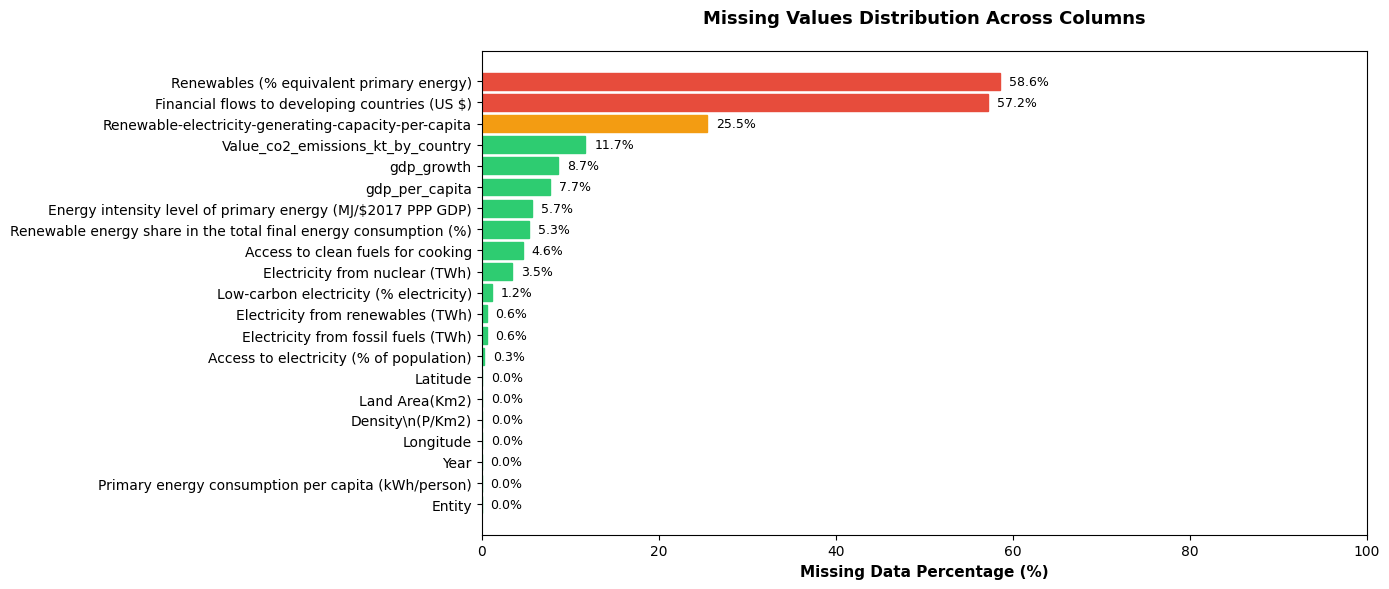


✓ Color coding: Green (<20%), Orange (20-50%), Red (>50%)


In [7]:
# Visualize missing values by column
fig, ax = plt.subplots(figsize=(14, 6))
missing_data_sorted = missing_data.sort_values('Missing_Percentage', ascending=True)
bars = ax.barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Percentage'])

# Color bars based on missing percentage
colors = ['#2ecc71' if x < 20 else '#f39c12' if x < 50 else '#e74c3c' for x in missing_data_sorted['Missing_Percentage']]
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax.set_xlabel('Missing Data Percentage (%)', fontsize=11, fontweight='bold')
ax.set_title('Missing Values Distribution Across Columns', fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(0, 100)

# Add percentage labels on bars
for i, (idx, row) in enumerate(missing_data_sorted.iterrows()):
    ax.text(row['Missing_Percentage'] + 1, i, f"{row['Missing_Percentage']:.1f}%", 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Color coding: Green (<20%), Orange (20-50%), Red (>50%)")

### Step 4: Data Type Conversions and Initial Cleaning

We'll now prepare the data by ensuring correct data types and handling any formatting issues.

In [8]:
# Create a copy for cleaning
df_cleaned = df_raw.copy()

# Standardize column names for consistency
df_cleaned.columns = df_cleaned.columns.str.strip()  # Remove leading/trailing whitespace

print("=" * 80)
print("DATA CLEANING OPERATIONS")
print("=" * 80)
print(f"\nOriginal shape: {df_raw.shape}")

# Check for duplicate rows
duplicates = df_cleaned.duplicated(subset=['Entity', 'Year']).sum()
print(f"Duplicate rows (same Entity and Year): {duplicates}")

# Ensure 'Year' column is integer type
df_cleaned['Year'] = pd.to_numeric(df_cleaned['Year'], errors='coerce').astype('Int64')

# Convert all other numeric columns
numeric_columns = df_cleaned.select_dtypes(include=['object']).columns.tolist()
numeric_columns.remove('Entity')  # Keep Entity as object

for col in numeric_columns:
    # Try to convert to numeric
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

print(f"\nConverted {len(numeric_columns)} columns to numeric types")
print("\nUpdated data types:")
print(df_cleaned.dtypes)

DATA CLEANING OPERATIONS

Original shape: (3649, 21)
Duplicate rows (same Entity and Year): 0

Converted 1 columns to numeric types

Updated data types:
Entity                                                                  str
Year                                                                  Int64
Access to electricity (% of population)                             float64
Access to clean fuels for cooking                                   float64
Renewable-electricity-generating-capacity-per-capita                float64
Financial flows to developing countries (US $)                      float64
Renewable energy share in the total final energy consumption (%)    float64
Electricity from fossil fuels (TWh)                                 float64
Electricity from nuclear (TWh)                                      float64
Electricity from renewables (TWh)                                   float64
Low-carbon electricity (% electricity)                              float64
Primary ene

### Step 5: Filter Irrelevant Data and Identify Core Metrics

We need to decide which columns and records to keep for analysis. This involves removing incomplete records and excluding columns with excessive missing values.

In [9]:
# Analyze countries and time range
print("=" * 80)
print("DATA SCOPE ANALYSIS")
print("=" * 80)

print(f"\nNumber of unique entities (countries): {df_cleaned['Entity'].nunique()}")
print(f"Year range: {df_cleaned['Year'].min()} to {df_cleaned['Year'].max()}")
print(f"Total records: {len(df_cleaned)}")

# Check data completeness by entity
entity_years = df_cleaned.groupby('Entity').size().reset_index(name='Year_Count')
print(f"\nEntity coverage statistics:")
print(f"  Mean years per entity: {entity_years['Year_Count'].mean():.1f}")
print(f"  Min years per entity: {entity_years['Year_Count'].min()}")
print(f"  Max years per entity: {entity_years['Year_Count'].max()}")
print(f"  Median years per entity: {entity_years['Year_Count'].median():.1f}")

# Identify which columns to focus on (those with reasonable data availability)
threshold_missing = 50  # Only keep columns with less than 50% missing

columns_to_keep = []
for col in df_cleaned.columns:
    missing_pct = (df_cleaned[col].isnull().sum() / len(df_cleaned)) * 100
    if missing_pct < threshold_missing or col in ['Entity', 'Year']:
        columns_to_keep.append(col)

print(f"\nColumns with <{threshold_missing}% missing data: {len(columns_to_keep)}")
print(f"Columns to exclude (>={threshold_missing}% missing): {df_cleaned.shape[1] - len(columns_to_keep)}")

# Keep only the selected columns
df_filtered = df_cleaned[columns_to_keep].copy()
print(f"\nFiltered dataset shape: {df_filtered.shape}")

DATA SCOPE ANALYSIS

Number of unique entities (countries): 176
Year range: 2000 to 2020
Total records: 3649

Entity coverage statistics:
  Mean years per entity: 20.7
  Min years per entity: 1
  Max years per entity: 21
  Median years per entity: 21.0

Columns with <50% missing data: 19
Columns to exclude (>=50% missing): 2

Filtered dataset shape: (3649, 19)


In [10]:
# Display selected columns and their missing data percentages
print("\n" + "=" * 80)
print("SELECTED COLUMNS (< 50% MISSING DATA)")
print("=" * 80)

selected_missing = []
for col in df_filtered.columns:
    missing_pct = (df_filtered[col].isnull().sum() / len(df_filtered)) * 100
    selected_missing.append({'Column': col, 'Missing %': f"{missing_pct:.1f}%"})

selected_df = pd.DataFrame(selected_missing)
print(selected_df.to_string(index=False))


SELECTED COLUMNS (< 50% MISSING DATA)
                                                          Column Missing %
                                                          Entity      0.0%
                                                            Year      0.0%
                         Access to electricity (% of population)      0.3%
                               Access to clean fuels for cooking      4.6%
            Renewable-electricity-generating-capacity-per-capita     25.5%
Renewable energy share in the total final energy consumption (%)      5.3%
                             Electricity from fossil fuels (TWh)      0.6%
                                  Electricity from nuclear (TWh)      3.5%
                               Electricity from renewables (TWh)      0.6%
                          Low-carbon electricity (% electricity)      1.2%
              Primary energy consumption per capita (kWh/person)      0.0%
     Energy intensity level of primary energy (MJ/$2017 PPP G